# ECON1059 Seminar 8
***
Notes for the Seminar Series on Python Programming for Economics (ECON1059, Fall 2025)
<br><br>
Juncheng ZHANG, PhD Candidate in Economics, UNNC.
<br><br>
Research interest: Behavioral and Experimental Economics. 
<br><br>
Email: Juncheng.ZHANG@nottingham.edu.cn
***

As we are approaching the destination of our seminar series, I have to remind you once again that the exam is **paper-based and closed-book**, so I strongly recommend that you work through the **[past papers](https://moodle.nottingham.ac.uk/course/view.php?id=153042)** from the last two years and start practising writing code by hand—although I have absolutely no idea what that feels like myself (I luckily don’t have to take the exam:D)—as I believe it will feel very different from typing on a computer.

## list comprehension
* List comprehension is a **short and elegant** way to create lists in Python.
* It allows you to generate a new list by looping, transforming, and filtering items — all in a single line.


* general structure：
```python
[new_item  for item in iterable  if condition]
```

* `new_item` — what you want to put into the new list

* `item` — each element from the original iterable

* `condition` — (optional) filter; only items that satisfy it will appear in the new list


Let's warm up with the easy stuff: Using list comprehension, create a list with the following items
* 1, 1/2, 1/3, ..., 1/10
* 3, 5, 7, 9, 11, ..., 19

In [1]:
li1 = [1/x for x in range(1,11)] # float number
print(li1)

[1.0, 0.5, 0.3333333333333333, 0.25, 0.2, 0.16666666666666666, 0.14285714285714285, 0.125, 0.1111111111111111, 0.1]


In [2]:
li2 = [x for x in range(3,20) if x%2 == 1] # modulo 
print(li2)

li2 = list(range(3, 20, 2))
print(li2)

[3, 5, 7, 9, 11, 13, 15, 17, 19]
[3, 5, 7, 9, 11, 13, 15, 17, 19]


* Vector addition using list comprehension: create a list resulting from an addition of the element of a first list with the respective element of a second list. 

In [3]:
# Vector Addition
li1 = [6, 6, 6, 6]
li2 = [4, 3, 2, 1]

li3 = [x + y for x, y in zip(li1, li2)]
print(list(zip(li1, li2)))
print(li3)

[(6, 4), (6, 3), (6, 2), (6, 1)]
[10, 9, 8, 7]


## Order of Growth (Hard)
* Order of Growth tells us how fast a program’s running time increases as the input size gets larger.
* It measures the overall trend of the runtime
* It helps us choose the efficient codes, especially when data becomes large.

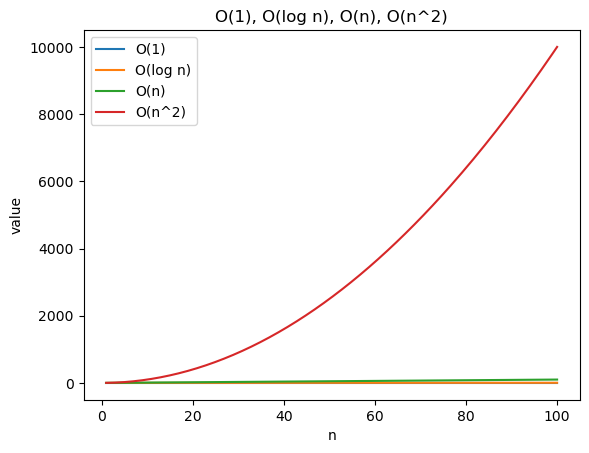

In [4]:
# Plotting different Big O notations
import matplotlib.pyplot as plt
import numpy as np

n = np.linspace(1, 100, 200)

f_const = np.ones_like(n)          # O(1)
f_log = np.log(n)                  # O(log n)
f_linear = n                       # O(n)
f_quad = n**2                      # O(n^2)

plt.figure()
plt.plot(n, f_const, label="O(1)")
plt.plot(n, f_log, label="O(log n)")
plt.plot(n, f_linear, label="O(n)")
plt.plot(n, f_quad, label="O(n^2)")

plt.legend()
plt.xlabel("n")
plt.ylabel("value")
plt.title("O(1), O(log n), O(n), O(n^2)")
plt.show()


In [5]:
## Example 1 O(1) Open the door
lst = [1, 2, 3, 4]
def get_first_element(lst): 
    return lst[0]  

get_first_element(lst)  # Returns 1

1

In [6]:
## Example 2 O(n) Check attendance
lst = [1, 2, 3, 4]
def print_elements(lst):
    for element in lst:
        print(element)

print_elements(lst)  # Prints each element

1
2
3
4


In [7]:
## Example 3 O(n^2)  Shake hands
def print_all_pairs(lst):
    for x in lst:
        for y in lst:
            print(x, y)

print_all_pairs([1, 2, 3])  # Prints all pairs

1 1
1 2
1 3
2 1
2 2
2 3
3 1
3 2
3 3


* Using the formal definition, show that the order of growth of $f(n) = 3n^4 + 2n^3 - n^2$ is $O(n^4)$.
  
The first thing you should realize is that for any non-negative real number $n\ge0$, $n^{a+1}$ is greater than $n^a$ for $n>1$, equal for $n=1$, and smaller for $0\le n < 1$.
<br>
As we are "doing computer science", starting with at least one datapoint, i.e., $n\ge1$, we don't have to worry about this (as we would need to under the more general defintion when all numbers are real-valued). Hence:

$f(n) = 3n^4 + 2n^3 - n^2 < 3n^4 + 2n^4 - 0 = 5n^4$

It follows that $f(n) \le M \cdot n^4$ with $M=5$, and so $f(n) = O(n^4)$. 

For polynomials, the Big-O is determined by the **highest power of n**.

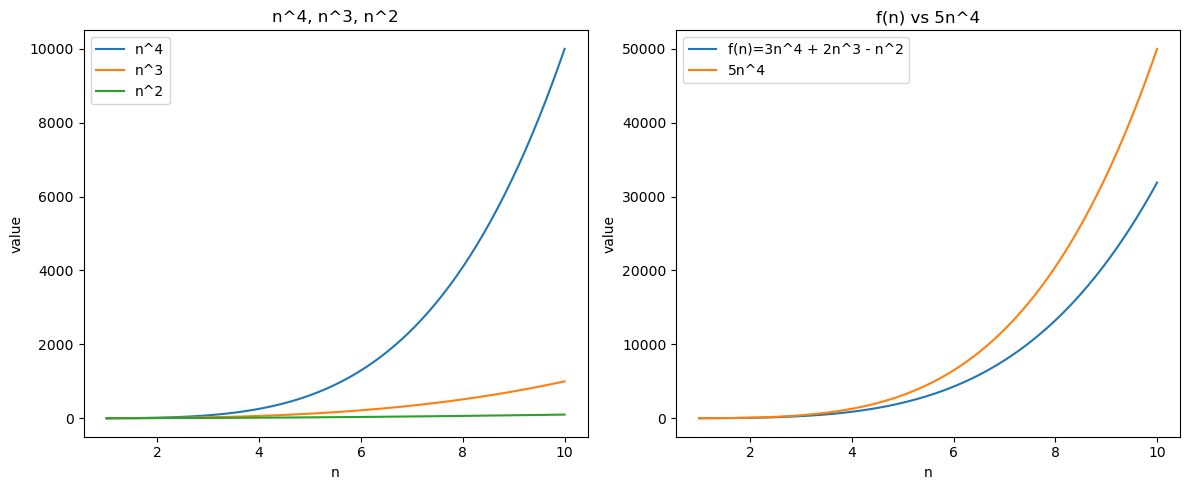

In [8]:

# Data
n = np.linspace(1, 10, 200)
f1 = n**4
f2 = n**3
f3 = n**2

fn = 3*n**4 + 2*n**3 - n**2
bound = 5*n**4

# Create side-by-side plots
fig, axes = plt.subplots(1, 2 , figsize=(12, 5))

# Left plot: n^4, n^3, n^2
axes[0].plot(n, f1, label="n^4")
axes[0].plot(n, f2, label="n^3")
axes[0].plot(n, f3, label="n^2")
axes[0].legend()
axes[0].set_xlabel("n")
axes[0].set_ylabel("value")
axes[0].set_title("n^4, n^3, n^2")

# Right plot: f(n) and 5n^4
axes[1].plot(n, fn, label="f(n)=3n^4 + 2n^3 - n^2")
axes[1].plot(n, bound, label="5n^4")
axes[1].legend()
axes[1].set_xlabel("n")
axes[1].set_ylabel("value")
axes[1].set_title("f(n) vs 5n^4")

plt.tight_layout()
plt.show()


## Search-like Algorithms
Suppose you have an unsorted list of numbers. 
1. Write a function that finds the maximum value.
1. What is the Time Complexity of your algorithm? 
1. Write a function that finds the minimum value. Can you do so by using your answers for part 1?

In [9]:
def find_maximum(numbers):
    max_value = numbers[0]
    
    for number in numbers:
        if number > max_value:
            max_value = number

    return max_value

In [10]:
print(find_maximum([7, 9, 3, 4]))

9


2. The algorithm makes one comparison for each item $\to$ $O(n)$

In [11]:
def find_minimum(numbers):
    reverse = [-number for number in numbers]  # [-7, -9, -3, -4]
    return -find_maximum(reverse)              # max = -3, -(-3) = 3

In [12]:
print(find_minimum([7, 9, 3, 4]))

3


* The solution re-uses existing functions instead of writing almost identical version of them. That's typically a good idea!
* Unfortunately, it is also quite inefficient, as the code itself has to create a new list, iterating over each item

* Look at the following two algorithms. What is their Order of Growth? Discuss.


In [13]:
def func_1(list_of_numbers):
    output = []
    for number in list_of_numbers:
        output.append(number**2)
    return output

def func_2(list_of_numbers):
    output = []
    for number in list_of_numbers:
        list_ = []
        list_.append(number)
        list_.append(number**2)
        list_.append(number**3)
        output.append(list_)
    return output

#### A quick look what they do:

In [14]:
print(func_1([1,2,3]))
print(func_2([1,2,3]))

[1, 4, 9]
[[1, 1, 1], [2, 4, 8], [3, 9, 27]]


* Both functions go over each element in the list of numbers exactly once. 
* Both are of order $O(n)$

* However, it is also self-evident that `func_2` has to complete many more computations than `func_1`. As such, it will take more time. (Feel free to verfy this with `time`; see next question.)
* In practise, writing functions that aren't terribly wasteful can be as important as finding an algorithm that is more efficient with respect to $n$.

## Estimating Compute Time with `time`

The lecture showed that Binary Search outperforms Linear Seach for larger datasets. But is this also true for small datasets? Use the time module to compare the two for lists with 4, 8, and 16 datapoints. Given that the algorithm will run very fast, consider running it 100 000 times to avoid small sample variance. (However, before doing so, compute it for a single run-time with a manually set list. Generalize after that works.)

* After solving the previous question, you should immediately see the idea behind this question. Looking at the code of the two algorithms, it is clear that *per loop*, linear search requires fewer computations than binary search.
* But then, it may be that for lists of around size 4, Binary Search may perform worse despite the fact that it only requires $T(4) = 3$ loops compared to the $4$ of Linear Search

#### Comment on official solution.
* The simplest way to solve this problem is to fix 3 sorted lists (why sorted?), one for each $n$. In order not to solve the exact same problem 100 000 times, you can pick a random number that should be found.
* I decided to generalize this idea a bit, generating a sorted list of randomly numbers each time. Sorry for complicating the solution : /

In [15]:
# Copy/Pasting our Search Algorithms
def linear_search(list_to_search, entry_to_find):
    for index, item in enumerate(list_to_search):
        if item == entry_to_find:
            return index
    return -1
    
def binary_search(list_to_search, entry_to_find):
    lowest_index = 0
    highest_index = len(list_to_search) - 1
    
    while lowest_index <= highest_index:
        middle_index = (lowest_index + highest_index) // 2
        if entry_to_find == list_to_search[middle_index]:
            return middle_index
        elif entry_to_find < list_to_search[middle_index]:  # here is why we need sorted list
            highest_index = middle_index - 1
        else:
            lowest_index = middle_index + 1
    return -1

In [16]:
import random

def random_sorted_list(length, num_rand_elements):
    """Returns a sorted list of of length length, with
    randomly generated from numbers 1, 2, ... num_rand_elements.
    """
    return sorted([random.randint(1, num_rand_elements) for x in range(length)]) # sorted order

# Test random_sorted_list
# Then you can use it to test your search algorithms (linear v.s. binary search)
print(random_sorted_list(10, 20))

[2, 4, 5, 5, 6, 9, 15, 16, 18, 20]


In [17]:
import time
import random

random.seed(64910666) # seed only fixes the random numbers, not the runtime.
num_iterations = 100000
num_random_elements = 100  # Fix to something; This will affect compute time
num_elements_li = [4, 8, 16]

compute_times_linear_search = [0]*len(num_elements_li)
compute_times_binary_search = [0]*len(num_elements_li)

for i, list_size in enumerate(num_elements_li): # i = 0 list_size = 4; i = 1 list_size = 8 and i = 2 list_size = 16     3 times
    for _ in range(num_iterations): # repeat for 100,000 times
        list_to_search = random_sorted_list(list_size, num_random_elements)  # (4, 100); (8, 100) and (16, 100)
        item_to_find = random.randint(1, num_random_elements) # (1, 100);  item_to_find is not necessarily in the list

        # Linear Search
        time_start = time.time()
        linear_search(list_to_search, item_to_find)
        compute_times_linear_search[i]+= time.time() - time_start 

         # Binary Search
        time_start = time.time()
        binary_search(list_to_search, item_to_find)
        compute_times_binary_search[i]+= time.time() - time_start

print(compute_times_linear_search)
print(compute_times_binary_search)

[0.045378923416137695, 0.03511357307434082, 0.04943346977233887]
[0.037439584732055664, 0.04226064682006836, 0.05004692077636719]


* There will always be slight variations in computing time. If your code is very quick, consider collecting repeated samples and compute the total or average time like we did above
* Indeed, if you do this often, consider upgrading to the advanced `timeit` module, which allows you to run the same code more than once in order to get a reliable estimate (https://docs.python.org/3/library/timeit.html)
* However, for much of what you do, a single run is usually informative enough

## Understanding Binary Search
The binary search algorithm uses a while loop with the condition `lowest_index <= highest_index`. Inside the while loop, if the item to find is not found at the mid-point, either the lowest or highest index is adjusted. Using the example `[2, 4, 5, 8, 9, 12, 17, 19, 25]`, show how the indices adjust with each iteration when the entry to find is either (a) 4, (b) 2, or (c) 1. Pay particular attention to when the while loop terminates.

You should try to solve this answer by hand first. 

However, a great way of understanding your code is always by making it tell you what is happening. One way to do this is as follows:

In [18]:
def binary_search_with_info(list_to_search, entry_to_find):
    lowest_index = 0
    highest_index = len(list_to_search)-1
    
    current_iteration = 1  # New
    print(f"Trying to find {entry_to_find} in {list_to_search}.\n")  # New
     
    while lowest_index <= highest_index:
        middle_index = (lowest_index + highest_index) // 2

        # Print out relevant information:
        # Note the effective list is just for you to visualize what we are left with. 
        # We actually adjust the indices, and always search over the original list in smaller and smaller ranges
        print(f"Current Round: {current_iteration}; Effective list: {list_to_search[lowest_index:highest_index+1]}")
        print(f"  lowest_index = {lowest_index}")
        print(f"  highest_index = {highest_index}")
        print(f"  middle_index = {middle_index}")
        print(f"  value at midpoint = {list_to_search[middle_index]}.")
        
        if entry_to_find == list_to_search[middle_index]:
            print(f"Item found at position {middle_index}. Search over.\n")
            return middle_index
        elif entry_to_find < list_to_search[middle_index]:
            highest_index = middle_index - 1
            print(f"Item not found. Adjusting highest index downward to {highest_index}.\n")
        else:
            lowest_index = middle_index + 1
            print(f"Item not found. Adjusting lowest index upward to {lowest_index}.\n")

        current_iteration += 1  # New
    
    print(f"Could not find item in list. Terminating Search.")
    return -1  # Not found

In [19]:
# Answer to (a)
list_to_search = [2, 4, 5, 8, 9, 12, 17, 19, 25]
entry_to_find = 4
location = binary_search_with_info(list_to_search, entry_to_find)

Trying to find 4 in [2, 4, 5, 8, 9, 12, 17, 19, 25].

Current Round: 1; Effective list: [2, 4, 5, 8, 9, 12, 17, 19, 25]
  lowest_index = 0
  highest_index = 8
  middle_index = 4
  value at midpoint = 9.
Item not found. Adjusting highest index downward to 3.

Current Round: 2; Effective list: [2, 4, 5, 8]
  lowest_index = 0
  highest_index = 3
  middle_index = 1
  value at midpoint = 4.
Item found at position 1. Search over.



In [20]:
# Answer to (b)
list_to_search = [2, 4, 5, 8, 9, 12, 17, 19, 25]
entry_to_find = 2
location = binary_search_with_info(list_to_search, entry_to_find)

Trying to find 2 in [2, 4, 5, 8, 9, 12, 17, 19, 25].

Current Round: 1; Effective list: [2, 4, 5, 8, 9, 12, 17, 19, 25]
  lowest_index = 0
  highest_index = 8
  middle_index = 4
  value at midpoint = 9.
Item not found. Adjusting highest index downward to 3.

Current Round: 2; Effective list: [2, 4, 5, 8]
  lowest_index = 0
  highest_index = 3
  middle_index = 1
  value at midpoint = 4.
Item not found. Adjusting highest index downward to 0.

Current Round: 3; Effective list: [2]
  lowest_index = 0
  highest_index = 0
  middle_index = 0
  value at midpoint = 2.
Item found at position 0. Search over.



In [21]:
# Answer to (c)
list_to_search = [2, 4, 5, 8, 9, 12, 17, 19, 25]
entry_to_find = 1
location = binary_search_with_info(list_to_search, entry_to_find)

Trying to find 1 in [2, 4, 5, 8, 9, 12, 17, 19, 25].

Current Round: 1; Effective list: [2, 4, 5, 8, 9, 12, 17, 19, 25]
  lowest_index = 0
  highest_index = 8
  middle_index = 4
  value at midpoint = 9.
Item not found. Adjusting highest index downward to 3.

Current Round: 2; Effective list: [2, 4, 5, 8]
  lowest_index = 0
  highest_index = 3
  middle_index = 1
  value at midpoint = 4.
Item not found. Adjusting highest index downward to 0.

Current Round: 3; Effective list: [2]
  lowest_index = 0
  highest_index = 0
  middle_index = 0
  value at midpoint = 2.
Item not found. Adjusting highest index downward to -1.

Could not find item in list. Terminating Search.


Finally, you can also try 20, or 26. Both of which are insightful